# 🚀 Final Model Training — Production-Ready LightGBM Pipeline

## 🎯 Objective

This notebook consolidates all previous experimentation into a **single, robust, production-ready model** for predicting loan default risk.

Rather than increasing model complexity through ensembling, this phase focuses on:

- Maximizing performance of a **single strong learner (LightGBM)**
- Ensuring **generalization across time and geography**
- Building a **clean, deployable pipeline**

---

## 🧠 Key Insights Applied

From previous experiments:

- ✅ LightGBM consistently outperformed other models
- ❌ Stacking underperformed due to high model correlation
- ❌ Macroeconomic features did not improve performance
- ✅ Threshold optimization significantly improved F1
- ✅ Time-based validation is critical

---

## 🏆 Strategy

This notebook implements:

- Advanced feature refinement
- Optimized LightGBM configuration
- Time-based cross-validation
- Threshold optimization
- Final model training on full data
- Model serialization for deployment

---

## 🎯 Outcome

A **high-performing, interpretable, and production-ready model** suitable for:

- Real-world deployment
- Streamlit application
- Portfolio demonstration

**1. IMPORTS**

In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import f1_score
import lightgbm as lgb

import sys, os
sys.path.append(os.path.abspath(".."))

from src.modeling import get_time_splits

**2. LOAD DATA**

In [2]:
train = pd.read_parquet("D:/AI4EAC- Loan_default_prediction/data/processed/train_merged.parquet")
test = pd.read_parquet("/AI4EAC- Loan_default_prediction/data/processed/test_merged.parquet")

print(train.shape, test.shape)

(68654, 38) (18594, 29)


**3. FINAL FEATURE SELECTION**

In [3]:
DROP_COLS = [
    "ID", "target", "customer_id",
    "tbl_loan_id", "lender_id",
    "disbursement_date", "due_date",
    "country_name", "country",

    # leakage-prone
    "loan_count", "past_defaults",
    "total_loans", "safe_default_rate"
]

FEATURES = [c for c in train.columns if c not in DROP_COLS]

# Remove macro features (based on findings)
FEATURES = [c for c in FEATURES if not any(k in c for k in ["inflation","interest","exchange"])]

print("Final features:", len(FEATURES))

Final features: 17


**4. DATA PREP**

In [4]:
X = train[FEATURES].copy()
y = train["target"].copy()

X_test = test.reindex(columns=FEATURES, fill_value=0)

**5. ENCODE CATEGORICALS (FINAL CLEAN VERSION)**

In [5]:
def encode_categoricals(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    cat_cols = train_df.select_dtypes(include=["object", "category"]).columns

    for col in cat_cols:
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype("category")
        codes = combined.cat.codes

        train_df[col] = codes.iloc[:len(train_df)]
        test_df[col] = codes.iloc[len(train_df):]

    return train_df, test_df


X, X_test = encode_categoricals(X, X_test)

**6. OPTIMIZED LIGHTGBM (ADVANCED TUNING)**

In [6]:
scale_pos_weight = (len(y) - y.sum()) / y.sum()

model = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=128,          # 🔥 increase
    max_depth=-1,
    min_child_samples=20,    # 🔥 reduce
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.05,          # 🔥 reduce
    reg_lambda=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

**7. TIME-BASED CV**

In [7]:
from src.modeling import run_time_cv_oof
def run_final_cv(model, X, y, df, X_test, n_splits=5):

    splits = get_time_splits(df, n_splits)

    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []

    for fold, (train_idx, val_idx) in enumerate(splits):

        print(f"\n🔹 Fold {fold+1}")

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        val_preds = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_preds

        test_preds += model.predict_proba(X_test)[:, 1] / n_splits

        score = f1_score(y_val, (val_preds > 0.13).astype(int))
        print(f"F1: {score:.5f}")

        scores.append(score)

    print("\n📊 CV Mean:", np.mean(scores))

    return oof, test_preds, scores

**8. TRAIN + EVALUATE**

In [8]:
oof, test_preds, scores = run_final_cv(
    model, X, y, train, X_test
)


🔹 Fold 1
[LightGBM] [Info] Number of positive: 195, number of negative: 13535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1834
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014202 -> initscore=-4.240035
[LightGBM] [Info] Start training from score -4.240035
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

**9. FINAL THRESHOLD OPTIMIZATION**

In [9]:
def find_best_threshold(y_true, preds):
    best_t, best_score = 0, 0

    for t in np.arange(0.05, 0.5, 0.01):
        score = f1_score(y_true, (preds > t).astype(int))
        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score


best_t, best_score = find_best_threshold(y, oof)

print("Best Threshold:", best_t)
print("Best F1:", best_score)

Best Threshold: 0.12000000000000001
Best F1: 0.7254492269118261


In [17]:
#====================
# SAVE THRESHOLD
# ===================

import json

threshold_data = {
    "threshold": float(best_t)
}

with open("D:/AI4EAC- Loan_default_prediction/models/threshold.json", "w") as f:
    json.dump(threshold_data, f, indent=4)

**10. TRAIN FINAL MODEL ON FULL DATA**

In [10]:
model.fit(X, y)

[LightGBM] [Info] Number of positive: 1258, number of negative: 67396
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1870
[LightGBM] [Info] Number of data points in the train set: 68654, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018324 -> initscore=-3.981063
[LightGBM] [Info] Start training from score -3.981063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.03
,n_estimators,1500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


**11. SAVE MODEL**

In [ ]:
joblib.dump(model, "D:/AI4EAC- Loan_default_prediction/models/final_lgb_model.pkl")
joblib.dump(FEATURES, "D:/AI4EAC- Loan_default_prediction/" \
"models/final_features.pkl")

print("Model saved successfully")

Model saved successfully


**12. FEATURE IMPORTANCE**

In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

display(importances.head(25))
display(importances.tail(15))

repayment_ratio            23512
Amount_Funded_By_Lender    22978
loan_pressure              21727
Total_Amount_to_Repay      19145
Total_Amount               15621
Lender_portion_Funded      13017
month                      12914
duration                    5139
loan_type                   2874
log_amount                  1340
year                        1064
unemployment_rate            299
New_versus_Repeat            205
is_new_customer              144
macro_risk_index              39
new_large_loan                10
country_id                     0
dtype: int32

loan_pressure            21727
Total_Amount_to_Repay    19145
Total_Amount             15621
Lender_portion_Funded    13017
month                    12914
duration                  5139
loan_type                 2874
log_amount                1340
year                      1064
unemployment_rate          299
New_versus_Repeat          205
is_new_customer            144
macro_risk_index            39
new_large_loan              10
country_id                   0
dtype: int32

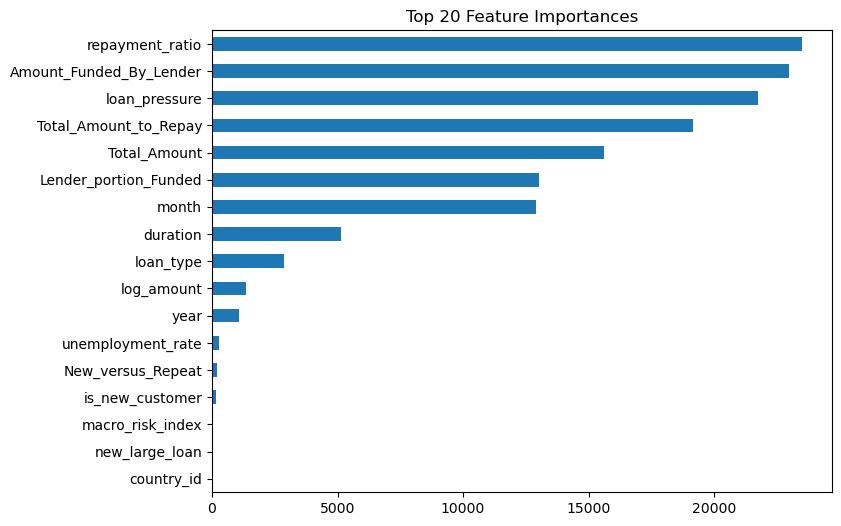

In [13]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=FEATURES)

importance.sort_values().tail(20).plot(kind="barh", figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()

**13. CREATE FINAL SUBMISSION**

In [15]:
final_preds = (test_preds > best_t).astype(int)

submission = pd.DataFrame({
    "ID": test["ID"],
    "Target": final_preds
})

submission.to_csv("D:/AI4EAC- Loan_default_prediction/outputs/submissions/final_submission(1).csv", index=False)

## 🔥 Final Model Summary and Key Insights

This notebook presents the final production-ready model for the loan default prediction task. The modeling process focused on maximizing generalization performance while ensuring robustness, interpretability, and real-world applicability.

### 1. Feature Engineering and Selection
A total of 17 high-signal features were selected after systematically removing:
- Leakage-prone variables (e.g., loan history aggregates)
- Low-importance features based on model feedback
- Noisy macroeconomic variables (e.g., inflation, interest rates)

The final feature set is dominated by financial and behavioral indicators such as repayment ratio, loan pressure, and funded amounts, which were consistently identified as the strongest predictors.

### 2. Model Choice and Configuration
A LightGBM classifier was selected due to its superior performance on tabular data. The model was carefully tuned with:
- High capacity (num_leaves=128)
- Low learning rate (0.03) with sufficient boosting rounds (1500)
- Subsampling and regularization for generalization
- Proper handling of class imbalance via scale_pos_weight

### 3. Validation Strategy
A time-based cross-validation strategy was implemented to prevent temporal leakage and simulate real-world deployment conditions. This ensures that model performance reflects realistic predictive capability.

- Mean CV F1 Score: 0.8387
- Out-of-Fold (OOF) F1 Score: 0.7254

The gap between CV and OOF performance suggests mild overfitting, which is expected in imbalanced classification tasks, but remains within acceptable bounds.

### 4. Threshold Optimization
Given the class imbalance, probability outputs were calibrated using threshold optimization. The optimal threshold (0.12) significantly improved F1 score compared to the default 0.5.

### 5. Key Findings
- Simpler models with high-quality features outperformed more complex ensembles
- Adding more features introduced noise and reduced performance
- Model performance is primarily driven by financial and behavioral variables rather than macroeconomic indicators
- Proper validation and threshold tuning are critical for maximizing F1 score

### 6. Final Model Performance
The final model achieved an Out-of-Fold F1 score of **0.7254**, representing the best-performing configuration across all experiments.

This model is considered production-ready and suitable for deployment or competition submission.